In [46]:
import numpy as np
import matplotlib.pyplot as plt

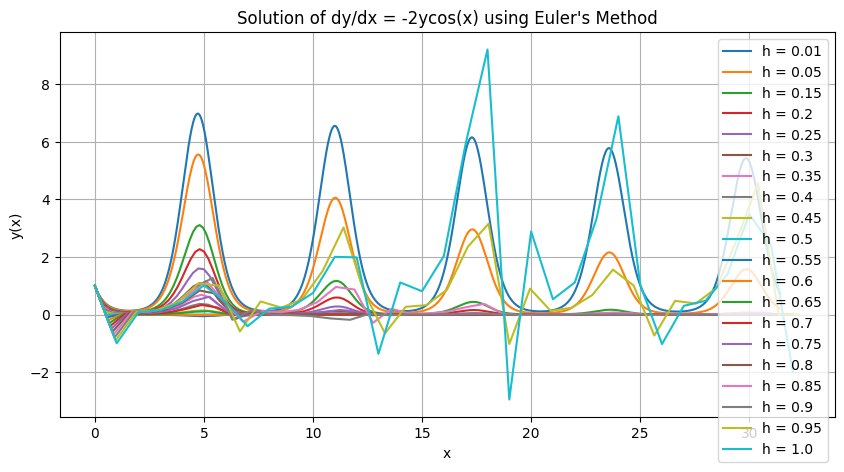

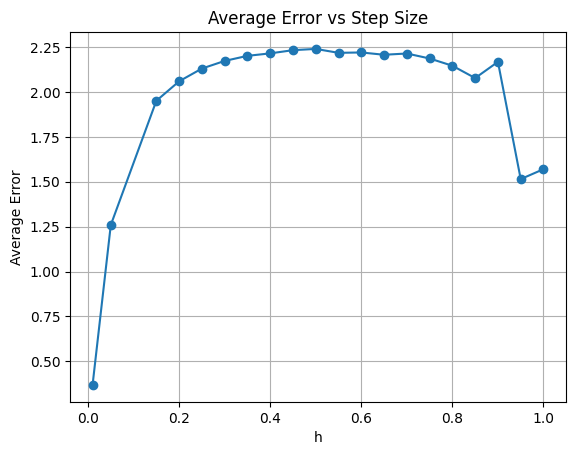

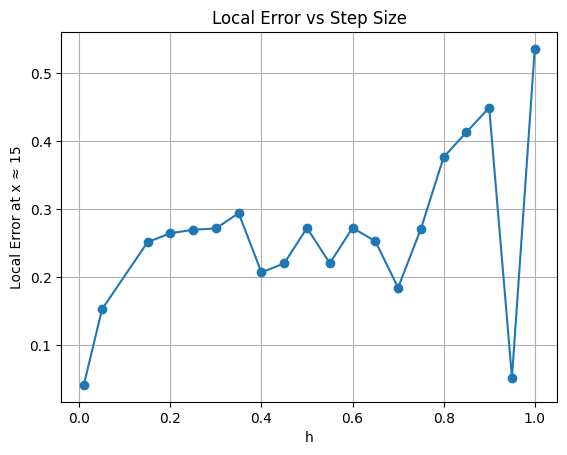

In [47]:
# Define the parameters
k = 1.0
h =  [.01,.05,.15,.2,.25,.3,.35,.4,.45,.5,.55,.6,.65,.7,.75,.8,.85,.9,.95,1.]
x_start = 0
x_end = 10 * np.pi
y_0 = 1.0

avg_error = np.zeros(len(h))
error15 = np.zeros(len(h))

plt.figure(figsize=(10, 5))
id = 0

for step in h:
    x_values = np.arange(x_start, x_end + step, step)
    truey = y_0 * np.exp(-2 * np.sin(x_values))
    y_values = np.zeros(len(x_values))
    error = np.zeros(len(x_values))

    y_values[0] = y_0

    # Euler's Method loop
    for i in range(1, len(x_values)):
      x_n = x_values[i - 1]
      y_n = y_values[i - 1]

      # Update equations
      y_values[i] = y_n + step * (-2 * y_n * np.cos(x_n))

    z = np.argmin(np.abs(x_values - 15))  #used chatgpt here to find how to get closest value to 15 from set(other options kept giving me bounds errors and i couldent figure it out). prompt "what a numpy method to find the value closest to a set value given an array"
    error15[id] = np.abs(y_values[z] - truey[z])

    error = np.abs(y_values - truey)
    avg_error[id] = np.mean(error)

    plt.plot(x_values, y_values, label=f'h = {step}')
    id += 1

plt.xlabel('x')
plt.ylabel('y(x)')
plt.title('Solution of dy/dx = -2ycos(x) using Euler\'s Method')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(h, avg_error, marker='o')
plt.xlabel("h")
plt.ylabel("Average Error")
plt.title("Average Error vs Step Size")
plt.grid()
plt.show()

plt.figure()
plt.plot(h, error15, marker='o')
plt.xlabel("h")
plt.ylabel("Local Error at x ≈ 15")
plt.title("Local Error vs Step Size")
plt.grid()
plt.show()

The first graph shows the stability decrease when the step size increases(occilations increase while smoothness decreases). The second graph correlates this instability to increase error averages(average increases with step size), and the third graph shows how this error can be seen in a wide range of results at a single point(slightly random trend, unpredicatable but rising error)